In [2]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from tslearn.clustering import TimeSeriesKMeans

# Pengaturan visualisasi
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 10})

print("✅ Pustaka tslearn dan alat visualisasi berhasil dimuat!")

c:\Users\hatta\AppData\Local\Programs\Python\Python314\Lib\site-packages\tslearn\bases\bases.py:16: UserWarning: h5py not installed, hdf5 features will not be supported.
Install h5py to use hdf5 features: http://docs.h5py.org/
  warn(h5py_msg)


✅ Pustaka tslearn dan alat visualisasi berhasil dimuat!


In [3]:
# 1. Tentukan Jalur File
base_dir = os.getcwd()
data_path = os.path.join(base_dir, 'Data', 'Processed', 'esp_data_final_preprocessed.csv')

# 2. Muat Data
df = pd.read_csv(r'C:\Users\hatta\ESP-FAILURE-DETECTION\Data\Processed\esp_data_final_preprocessed.csv')
print(f"Total data keseluruhan: {df.shape[0]} baris.")

# 3. Filter Hanya Mesin yang Rusak (Downtime > 0)
df_rusak = df[df['Downtime'] > 0].copy()
print(f"Data mesin rusak (bahan belajar AI): {df_rusak.shape[0]} baris.")

# 4. Ambil 9 Parameter Emas
fitur = [
    'Freq', 'Current', 'Vibration', 'Intake_Press', 
    'Motor_Temp', 'Gas_Sat', 'Delta_Press', 'Pwr_Diff', 'Liq_Intake'
]

# 5. Bentuk Ulang (Reshape) untuk tslearn: (Jumlah Data, Timestep, Fitur)
X_rusak = df_rusak[fitur].values.reshape(-1, 1, 9)
print(f"Dimensi Matriks AI: {X_rusak.shape}")


Total data keseluruhan: 22934 baris.
Data mesin rusak (bahan belajar AI): 2378 baris.
Dimensi Matriks AI: (2378, 1, 9)


In [7]:
print("Memulai pencarian 5 Klaster Kerusakan (Mohon tunggu...) ⏳")

# Menjalankan AI Clustering
# n_clusters=5 mewakili 5 pola kerusakan (Gas Lock, Keausan, dll)
model_clustering = TimeSeriesKMeans(n_clusters=5, metric="dtw", max_iter=10, random_state=42)
model_clustering.fit(X_rusak)

# Mengekstrak pola rata-rata (Barycenter)
pusat_klaster = model_clustering.cluster_centers_

# ==========================================
# PENYESUAIAN DIREKTORI PENYIMPANAN
# ==========================================
import os
import numpy as np

# 1. Mundur 1 langkah dari folder 'notebooks' ke root 'ESP_Failure_Detection'
base_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))

# 2. Arahkan ke folder 'models' (menggunakan huruf kecil sesuai folder tree)
output_dir = os.path.join(base_dir, 'models')
os.makedirs(output_dir, exist_ok=True)

# 3. Tentukan nama file lengkap (menghapus pengulangan kata 'Models')
output_path = os.path.join(output_dir, 'anomaly_library_centers.npy')

# 4. Simpan file
np.save(output_path, pusat_klaster)

print(f"\n✅ SUKSES! File kamus berhasil diciptakan!")
print(f"📂 Tersimpan di: {output_path}")

Memulai pencarian 5 Klaster Kerusakan (Mohon tunggu...) ⏳

✅ SUKSES! File kamus berhasil diciptakan!
📂 Tersimpan di: c:\Users\hatta\ESP-FAILURE-DETECTION\models\anomaly_library_centers.npy


✅ Gambar 5 Pola berhasil dicetak dengan resolusi HD!
📂 Tersimpan di: c:\Users\hatta\ESP-FAILURE-DETECTION\reports\figures\5_pola_kerusakan.png


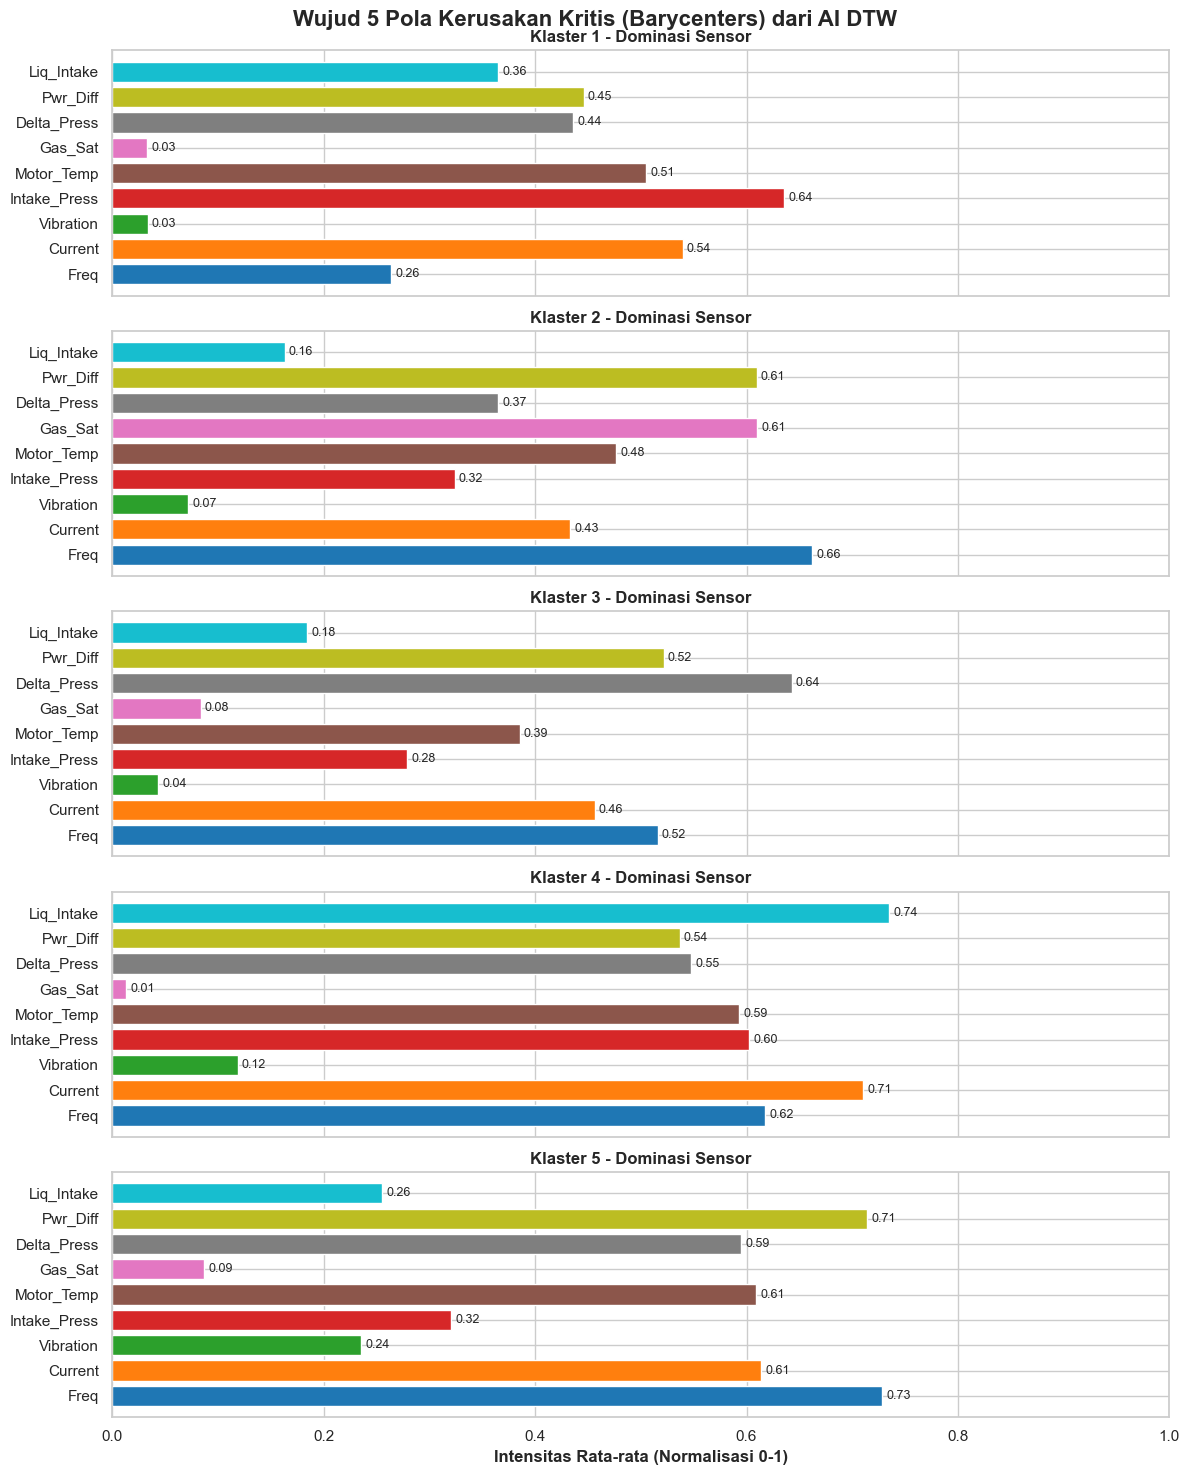

In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Menyiapkan kanvas besar untuk 5 klaster
fig, axes = plt.subplots(5, 1, figsize=(12, 15), sharex=True)
fig.suptitle("Wujud 5 Pola Kerusakan Kritis (Barycenters) dari AI DTW", fontsize=16, fontweight='bold', y=0.98)

# Warna berbeda untuk membedakan sensor
colors = plt.cm.tab10(np.linspace(0, 1, 9))

for i in range(5):
    ax = axes[i]
    # Ambil data klaster ke-i, buang dimensi timestep yang cuma 1
    pola_klaster = pusat_klaster[i, 0, :] 
    
    # Plot 9 parameter sebagai bar chart horizontal untuk melihat dominasi sensor di klaster tersebut
    bars = ax.barh(fitur, pola_klaster, color=colors)
    
    ax.set_title(f"Klaster {i+1} - Dominasi Sensor", fontweight='bold')
    ax.set_xlim(0, 1) # Karena data sudah dinormalisasi 0-1
    
    # Tambahkan angka di sebelah bar
    for bar in bars:
        width = bar.get_width()
        ax.annotate(f'{width:.2f}',
                    xy=(width, bar.get_y() + bar.get_height() / 2),
                    xytext=(3, 0),  # 3 points offset
                    textcoords="offset points",
                    ha='left', va='center', fontsize=9)

plt.xlabel("Intensitas Rata-rata (Normalisasi 0-1)", fontweight='bold')
plt.tight_layout()

# ==========================================
# PENYESUAIAN DIREKTORI PENYIMPANAN GAMBAR
# ==========================================
# 1. Pastikan mundur 1 langkah ke root proyek (keluar dari folder notebooks)
base_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))

# 2. Arahkan spesifik ke folder reports/figures
output_dir = os.path.join(base_dir, 'reports', 'figures')

# 3. Wajib: Suruh Python membuat foldernya jika belum ada
os.makedirs(output_dir, exist_ok=True) 

# 4. Tentukan jalur lengkap gambar
gambar_path = os.path.join(output_dir, '5_pola_kerusakan.png')

# 5. Simpan gambar (Pastikan posisi ini SEBELUM plt.show)
plt.savefig(gambar_path, dpi=300, bbox_inches='tight')
print(f"✅ Gambar 5 Pola berhasil dicetak dengan resolusi HD!")
print(f"📂 Tersimpan di: {gambar_path}")

# Tampilkan di Jupyter Notebook
plt.show()